<a href="https://colab.research.google.com/github/JorgeRf07/Diplomado-Redes-Neuronales-Artificiales/blob/main/Clima_y_Pron%C3%B3stico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
URL = "https://raw.githubusercontent.com/florian-huber/weather_prediction_dataset/refs/heads/main/dataset/weather_prediction_dataset.csv"
df = pd.read_csv(URL)
df.head(10)

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-9.3,0.7,1.6,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,0.5,2.0,2.0,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-1.0,2.8,3.4,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,2.5,4.6,4.9,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-1.8,2.9,3.6,0.95,1.0209,0.39,0.04,8.0,6.4,9.5
5,20000106,1,3,0.85,1.0244,0.56,0.00,5.7,4.2,1.9,...,-0.6,4.0,3.4,0.92,1.0209,0.55,0.20,7.1,3.5,10.7
6,20000107,1,8,0.84,1.0267,0.20,0.00,0.0,4.7,1.8,...,1.7,4.1,2.8,0.96,1.0258,0.27,0.00,6.0,3.3,8.8
7,20000108,1,4,0.79,1.0248,0.54,0.00,4.3,5.6,4.1,...,3.5,6.4,3.6,0.97,1.0210,0.18,0.14,8.2,5.3,11.0
8,20000109,1,8,0.88,1.0243,0.11,0.65,0.0,4.6,3.8,...,3.3,5.1,3.0,0.91,1.0280,0.43,0.02,5.6,3.7,7.6
9,20000110,1,8,0.91,1.0337,0.06,0.09,0.0,2.4,1.4,...,0.0,5.5,1.9,0.94,1.0369,0.58,0.04,1.8,-1.5,5.0


In [8]:
#Preprocesameinto
#limpia de datos
#y = ["Selling_PriceDATE"]
#X = df.drop(["Car_Name","Seller_Type","Owner"])
print(df.info())
#analizamos si existen datos nulos y en caso de que hubiese 30% de datos nulos o mas, se elimina la columna
#en caso contrario se mantiene
nulo = df.isnull().sum()
print(nulo)
duplicados = df.duplicated().sum()
print(duplicados)
#eliminar duplicados
df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Columns: 165 entries, DATE to TOURS_temp_max
dtypes: float64(150), int64(15)
memory usage: 4.6 MB
None
DATE                      0
MONTH                     0
BASEL_cloud_cover         0
BASEL_humidity            0
BASEL_pressure            0
                         ..
TOURS_global_radiation    0
TOURS_precipitation       0
TOURS_temp_mean           0
TOURS_temp_min            0
TOURS_temp_max            0
Length: 165, dtype: int64
0


In [9]:
#Dividir datos en X e y
y = df["TOURS_precipitation"]

# Crear el conjunto de características X, excluyendo la variable objetivo ('TOURS_precipitation'),
# 'DATE' y 'MONTH' (que son identificadores y no características predictivas directamente).
X = df.drop(["TOURS_precipitation", "DATE", "MONTH"], axis=1)

# Convertir datos categóricos objeto a datos numéricos (si los hubiera).
# Actualmente, todas las columnas restantes son numéricas, por lo que no se necesita LabelEncoder aquí.
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# X["Fuel_Type"] = le.fit_transform(X["Fuel_Type"])
# X["Transmission"] = le.fit_transform(X["Transmission"])
print("Características (X):")
print(X.head())
print("Variable Objetivo (y):")
print(y.head())

Características (X):
   BASEL_cloud_cover  BASEL_humidity  BASEL_pressure  BASEL_global_radiation  \
0                  8            0.89          1.0286                    0.20   
1                  8            0.87          1.0318                    0.25   
2                  5            0.81          1.0314                    0.50   
3                  7            0.79          1.0262                    0.63   
4                  5            0.90          1.0246                    0.51   

   BASEL_precipitation  BASEL_sunshine  BASEL_temp_mean  BASEL_temp_min  \
0                 0.03             0.0              2.9             1.6   
1                 0.00             0.0              3.6             2.7   
2                 0.00             3.7              2.2             0.1   
3                 0.35             6.9              3.9             0.5   
4                 0.07             3.7              6.0             3.8   

   BASEL_temp_max  BUDAPEST_cloud_cover  ...  S

In [4]:
#Escalado de datos
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)
print(X)
#Dividir datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)


[[ 1.11026048  1.34443286  1.34700635 ... -0.57309729 -0.11605711
  -0.87527802]
 [ 1.11026048  1.15885725  1.74895394 ... -0.66588649 -0.22147789
  -0.95306001]
 [-0.17996271  0.6021304   1.69871049 ... -0.63495676 -0.22147789
  -0.90120535]
 ...
 [ 1.11026048  1.62279629 -2.50917828 ... -0.3411243   0.14749485
  -0.68082304]
 [ 0.68018609  1.71558409 -2.77295638 ... -0.57309729 -0.29175841
  -0.7326777 ]
 [ 1.11026048  1.71558409 -2.68503035 ... -1.81028658 -1.50409742
  -1.91237124]]


In [10]:
print(f"El DataFrame X_train tiene {X_train.shape[1]} columnas.")

El DataFrame X_train tiene 162 columnas.


In [11]:
#Modelo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Obtener el número de características de X_train para el input_shape dinámico
num_features = X_train.shape[1]

modelo = Sequential([
    Dense(21, activation="relu", input_shape=(num_features,)),
    Dense(20, activation="relu"),
    Dense(1, activation="linear")
])
#Entrenamos el modelo
modelo.compile(optimizer="adam", loss=["mse"], metrics=["mae"])
historial = modelo.fit(X_train, y_train, epochs = 200, batch_size=16,validation_split=0.2)

Epoch 1/200


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3137 - mae: 0.3687 - val_loss: 0.1764 - val_mae: 0.2616
Epoch 2/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1643 - mae: 0.2438 - val_loss: 0.1545 - val_mae: 0.2410
Epoch 3/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1449 - mae: 0.2215 - val_loss: 0.1393 - val_mae: 0.2305
Epoch 4/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1329 - mae: 0.2105 - val_loss: 0.1372 - val_mae: 0.2324
Epoch 5/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1250 - mae: 0.2061 - val_loss: 0.1362 - val_mae: 0.2194
Epoch 6/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1174 - mae: 0.1980 - val_loss: 0.1352 - val_mae: 0.2166
Epoch 7/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1103 - mae: 0.1904 - val_loss: 0.1376 - val_mae: 0.2368
Epoch 8/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1062 - mae: 0.1902 - val_loss: 0.1313 - val_mae: 0.2190
Epoch 9/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss:

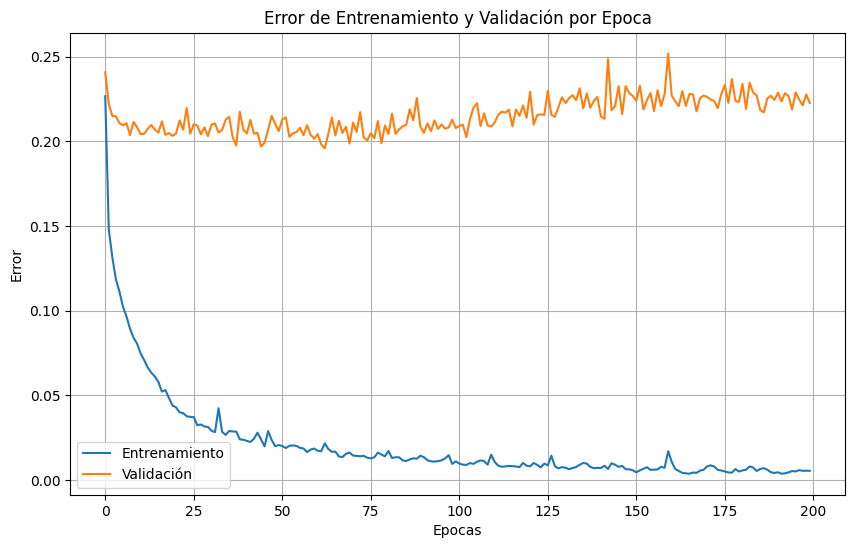

In [14]:
#Graficar los errores
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(historial.history["loss"], label="Entrenamiento")
plt.plot(historial.history["val_loss"], label="Validación")
plt.xlabel("Epocas")
plt.ylabel("Error")
plt.title("Error de Entrenamiento y Validación por Epoca")
plt.legend()
plt.grid(True)
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


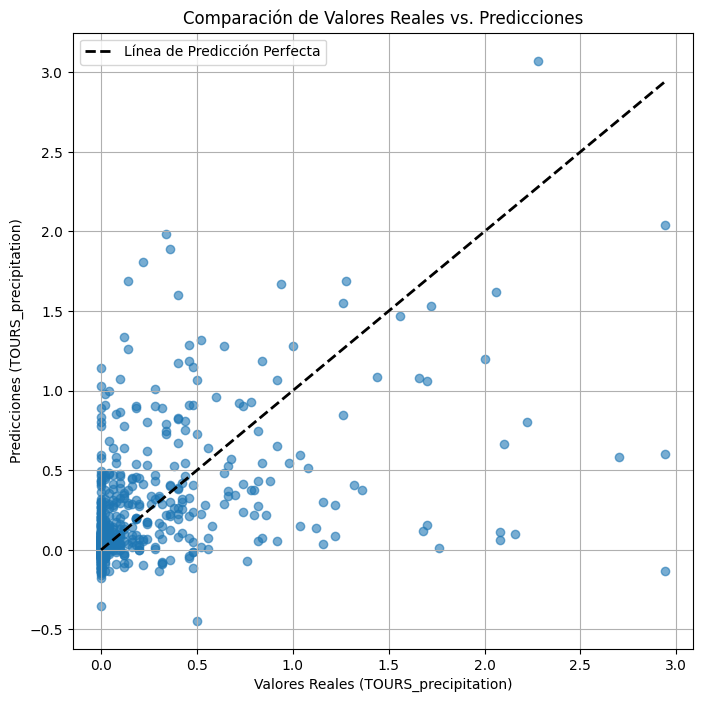

In [18]:
#Comparar las predicciones vs los datos reales
y_pred = modelo.predict(X_test)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Valores Reales (TOURS_precipitation)")
plt.ylabel("Predicciones (TOURS_precipitation)")
plt.title("Comparación de Valores Reales vs. Predicciones")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Línea de Predicción Perfecta')
plt.grid(True)
plt.legend()
plt.show()

In [18]:
#Comparacion numerica entre el dato real y el dato predicho
#y_test vs y_pred
print("Primeros 10 valores reales: ", y_test[:10].values)
print("Primeros 10 valores predichos: ", y_pred[:10].flatten())

Primeros 10 valores reales:  [0.   0.   0.04 0.   0.02 0.   0.   0.02 0.02 0.  ]
Primeros 10 valores predichos:  [ 0.02181209 -0.05209964  0.09455592  0.05343271  0.08849428 -0.0084578
  0.21931815  0.19186959 -0.05685358 -0.12297457]


### Predicción Binaria de Lluvia (Clasificación)

Ahora, para predecir si 'lloverá' o 'no lloverá', convertiremos las predicciones de precipitación continua en una clasificación binaria. Estableceremos un umbral: si la precipitación predicha es mayor que 0.01 (un valor muy pequeño para considerar que hay lluvia), se clasificará como 'lloverá'.

Umbral de lluvia utilizado: 0.01

--- Métricas de Clasificación ---
Precisión (Accuracy): 0.6416

Reporte de Clasificación:
              precision    recall  f1-score   support

   No Lluvia       0.74      0.44      0.55       367
      Lluvia       0.60      0.84      0.70       364

    accuracy                           0.64       731
   macro avg       0.67      0.64      0.63       731
weighted avg       0.67      0.64      0.63       731


Matriz de Confusión:
[[162 205]
 [ 57 307]]


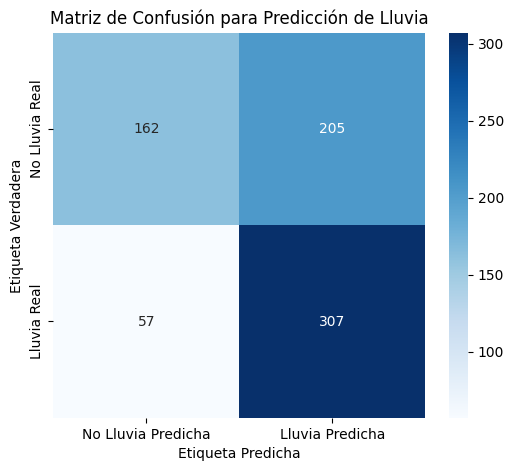

In [19]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Definir un umbral para la clasificación de 'lluvia'
umbral_lluvia = 0.01

# Convertir los valores reales de y_test a binario (1 si > umbral, 0 si <= umbral)
y_test_binary = (y_test > umbral_lluvia).astype(int)

# Convertir las predicciones del modelo a binario
y_pred_binary = (y_pred.flatten() > umbral_lluvia).astype(int)

print(f"Umbral de lluvia utilizado: {umbral_lluvia}")
print("\n--- Métricas de Clasificación ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test_binary, y_pred_binary):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test_binary, y_pred_binary, target_names=['No Lluvia', 'Lluvia']))

print("\nMatriz de Confusión:")
conf_matrix = confusion_matrix(y_test_binary, y_pred_binary)
print(conf_matrix)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Lluvia Predicha', 'Lluvia Predicha'],
            yticklabels=['No Lluvia Real', 'Lluvia Real'])
plt.title('Matriz de Confusión para Predicción de Lluvia')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.show()

In [22]:
print('--- Probando diferentes umbrales para reducir falsos positivos ---')

# Definir una lista de umbrales a probar
umbrales_a_probar = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2]

for umbral in umbrales_a_probar:
    print(f"\n=== Evaluando con umbral_lluvia = {umbral} ===")

    # Convertir los valores reales de y_test a binario con el nuevo umbral
    y_test_binary_current = (y_test > umbral).astype(int)

    # Convertir las predicciones del modelo a binario con el nuevo umbral
    y_pred_binary_current = (y_pred.flatten() > umbral).astype(int)

    print(f"Precisión (Accuracy): {accuracy_score(y_test_binary_current, y_pred_binary_current):.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test_binary_current, y_pred_binary_current, target_names=['No Lluvia', 'Lluvia']))

    print("\nMatriz de Confusión:")
    conf_matrix_current = confusion_matrix(y_test_binary_current, y_pred_binary_current)
    print(conf_matrix_current)

    # Opcional: Visualizar cada matriz de confusión (descomentar si se desea)
    # plt.figure(figsize=(6, 5))
    # sns.heatmap(conf_matrix_current, annot=True, fmt='d', cmap='Blues',
    #             xticklabels=['No Lluvia Predicha', 'Lluvia Predicha'],
    #             yticklabels=['No Lluvia Real', 'Lluvia Real'])
    # plt.title(f'Matriz de Confusión (Umbral: {umbral})')
    # plt.ylabel('Etiqueta Verdadera')
    # plt.xlabel('Etiqueta Predicha')
    # plt.show()

--- Probando diferentes umbrales para reducir falsos positivos ---

=== Evaluando con umbral_lluvia = 0.005 ===
Precisión (Accuracy): 0.6197

Reporte de Clasificación:
              precision    recall  f1-score   support

   No Lluvia       0.73      0.39      0.51       367
      Lluvia       0.58      0.85      0.69       364

    accuracy                           0.62       731
   macro avg       0.65      0.62      0.60       731
weighted avg       0.65      0.62      0.60       731


Matriz de Confusión:
[[142 225]
 [ 53 311]]

=== Evaluando con umbral_lluvia = 0.01 ===
Precisión (Accuracy): 0.6416

Reporte de Clasificación:
              precision    recall  f1-score   support

   No Lluvia       0.74      0.44      0.55       367
      Lluvia       0.60      0.84      0.70       364

    accuracy                           0.64       731
   macro avg       0.67      0.64      0.63       731
weighted avg       0.67      0.64      0.63       731


Matriz de Confusión:
[[162 205]
